<a href="https://colab.research.google.com/github/anshi-tech/DataScience-project/blob/main/ZomatoDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Understanding customer preferences and restaurant trends is important for making informed business decisions in food industry. In this article, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights. We aim to answer questions such as:

Do more restaurants provide online delivery compared to offline services?

Which types of restaurants are most favored by the general public?

What price range do couples prefer for dining out?

In [ ]:
import pandas as pd #data maniplulation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Seaborn is a Python library for creating statistical visualizations.
# It provides clean default styles and color palettes, making plots more attractive and easier to read.
# Built on top of Matplotlib and integrated with pandas data structures, Seaborn makes data visualization easier and more consistent.

In [ ]:
df = pd.read_csv("Zomato-data-.csv")
print(df)
#we can also make our own dataframe
# dic={"name":["Anshika","Yashika","Momika"],"marks":[99,98,100]}
# dataframe=pd.DataFrame(dic)
# print(dataframe)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [ ]:
#checking for missing value
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


In [ ]:
def handleRate(value):
  value=str(value).split('/')# Step 1: Convert to string and split at '/'
  value=value[0];            # Step 2: Take the first part before '/'
  return float(value)        # Step 3: Convert that part to a float

df['rate'] = df['rate'].apply(handleRate)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [ ]:
#get summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


Text(0.5, 0, 'Type of restaurant')

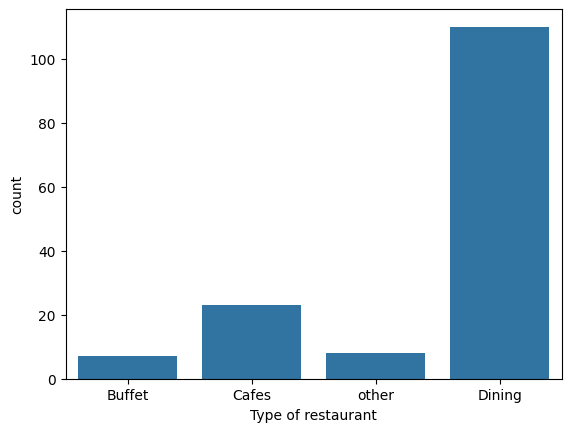

In [ ]:
# Exploring Restaurant Types
# Let's see the listed_in (type) column to identify popular restaurant categories.
sns.countplot(x=df['listed_in(type)'])#by using seaborn library, we are constructing bar plot(countplot)
plt.xlabel("Type of restaurant")

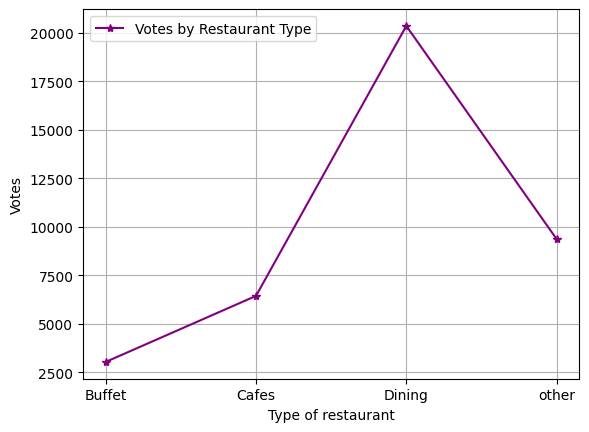

In [ ]:
#make the group of rows of same listed_in type, Selects only the votes column from each group.
#sum up the votes for each restaurant type.
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, color='purple', marker='*',label='Votes by Restaurant Type')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')
plt.legend()
plt.grid(True)

In [ ]:
from pandas.core.indexing import maybe_convert_ix
#most voted restaurant
maxVote = df['votes'].max()
print("maximum vote = ",maxVote)
restaurantWithMaxVote = df.loc[df['votes']==maxVote, 'name']

print("Restaurant(s) with the maximum votes :\n",restaurantWithMaxVote)

maximum vote =  4884
Restaurant(s) with the maximum votes :
 38    Empire Restaurant
Name: name, dtype: object


<Axes: xlabel='online_order', ylabel='count'>

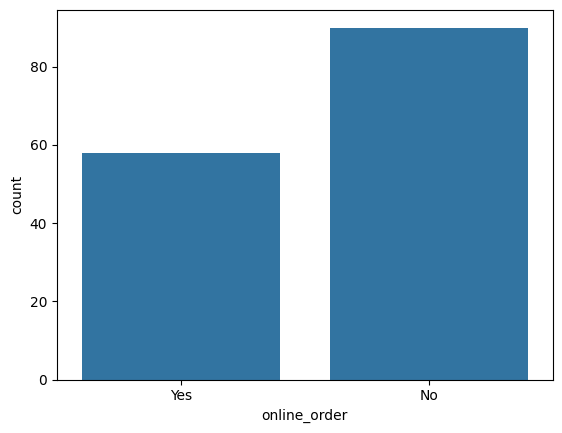

In [ ]:
# create bar plot of on;ine order
sns.countplot(x=df['online_order'])

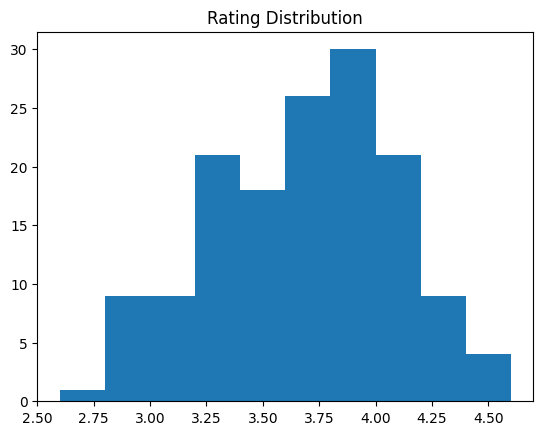

In [ ]:
#Analyze Rating with help of histogram from matplotlib
plt.hist(df['rate'],bins = 10)
plt.title('Rating Distribution')
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

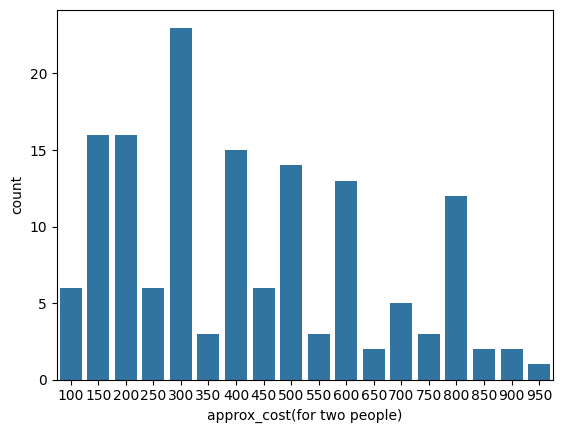

In [ ]:
# Approximate Cost for couples
sns.countplot(x=df['approx_cost(for two people)'])

Text(0.5, 1.0, 'Rating Distribution by Online Order (Boxplot)')

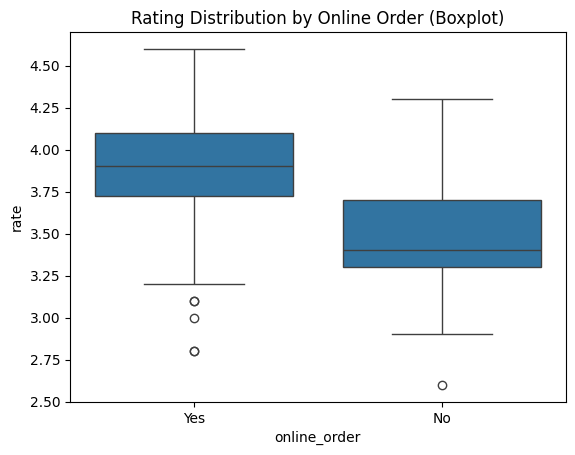

In [ ]:
#Rating Comparison
sns.boxplot(x = 'online_order', y = 'rate', data = df)
plt.title('Rating Distribution by Online Order (Boxplot)')

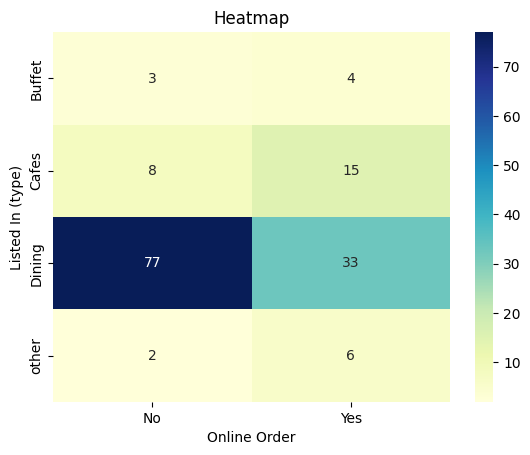

In [ ]:
#Order mode preferences by Restaurant Type
#creating pivot table
pivot_table = df.pivot_table(index = 'listed_in(type)',# Rows will be grouped by the values in this column
      columns = 'online_order',                        # Columns will be grouped by the values in this column
      aggfunc = 'size',                                # Count the number of rows in each group
      fill_value=0                                     # Replace NaN with 0
)
#Plotting the Heatmap
sns.heatmap(pivot_table,       # Data to visualize
    annot=True,                # Show the numbers inside the cells
    cmap='YlGnBu',             # Yellow-Green-Blue color gradient
    fmt='d'                    # Format numbers as integers
)
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (type)')
plt.show()